In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, FileLink

mpl.rcParams['animation.embed_limit'] = 100.0

# --- 1. Physics & Simulation Hyperparameters ---
NUM_BOIDS = 5000
WIDTH, HEIGHT = 300.0, 300.0
PERCEPTION_RADIUS = 15.0
SEPARATION_RADIUS = 5.0

WEIGHT_SEPARATION = 1.5
WEIGHT_ALIGNMENT = 1.0
WEIGHT_COHESION = 1.0

MAX_SPEED = 2.5
MAX_FORCE = 0.08

# --- 2. JIT-Compiled Parallel Physics Kernel ---
@njit(parallel=True, fastmath=True)
def update_boids_numba(positions, velocities, width, height, 
                       perception_radius, separation_radius,
                       w_sep, w_ali, w_coh, max_force, max_speed):
    N = positions.shape[0]
    accelerations = np.zeros_like(positions)
    
    # Pre-create bounds array for Numba compatibility
    bounds = np.array([width, height])
    
    for i in prange(N):
        pos_i = positions[i]
        vel_i = velocities[i]
        
        sep_force = np.zeros(2)
        ali_force = np.zeros(2)
        coh_force = np.zeros(2)
        
        neighbor_count = 0
        sep_count = 0
        
        center_of_mass = np.zeros(2)
        avg_velocity = np.zeros(2)
        
        for j in range(N):
            if i == j:
                continue
                
            dx = pos_i[0] - positions[j, 0]
            dy = pos_i[1] - positions[j, 1]
            dx -= width * np.round(dx / width)
            dy -= height * np.round(dy / height)
            
            dist_sq = dx*dx + dy*dy
            
            if dist_sq < perception_radius**2 and dist_sq > 0:
                dist = np.sqrt(dist_sq)
                neighbor_count += 1
                avg_velocity += velocities[j]
                center_of_mass += positions[j]
                
                if dist < separation_radius:
                    sep_force[0] += dx / (dist_sq + 1e-6)
                    sep_force[1] += dy / (dist_sq + 1e-6)
                    sep_count += 1
                    
        if sep_count > 0:
            accelerations[i] += sep_force * w_sep
            
        if neighbor_count > 0:
            avg_velocity /= neighbor_count
            ali_force = avg_velocity - vel_i
            accelerations[i] += ali_force * w_ali
            
            center_of_mass /= neighbor_count
            coh_force = (center_of_mass - pos_i) - vel_i
            accelerations[i] += coh_force * w_coh
            
        f_mag = np.sqrt(accelerations[i, 0]**2 + accelerations[i, 1]**2)
        if f_mag > max_force:
            accelerations[i] = (accelerations[i] / f_mag) * max_force
            
    velocities += accelerations
    
    speeds = np.sqrt(velocities[:, 0]**2 + velocities[:, 1]**2)
    over_speed = speeds > max_speed
    for idx in range(N):
        if over_speed[idx]:
            velocities[idx] = (velocities[idx] / speeds[idx]) * max_speed
            
    # FIXED: Convert bounds list to NumPy array for modulo operator
    positions = (positions + velocities) % bounds
    return positions, velocities

# --- 3. Benchmark Execution ---
positions = np.random.rand(NUM_BOIDS, 2) * [WIDTH, HEIGHT]
angles = np.random.rand(NUM_BOIDS) * 2 * np.pi
speeds = np.random.uniform(0.5 * MAX_SPEED, MAX_SPEED, NUM_BOIDS)
velocities = np.column_stack((np.cos(angles) * speeds, np.sin(angles) * speeds))

# Warm-up compile
_ = update_boids_numba(positions[:100], velocities[:100], WIDTH, HEIGHT, 
                       PERCEPTION_RADIUS, SEPARATION_RADIUS, 
                       WEIGHT_SEPARATION, WEIGHT_ALIGNMENT, WEIGHT_COHESION, 
                       MAX_FORCE, MAX_SPEED)

# Benchmark 100 Steps
t0 = time.time()
for _ in range(100):
    positions, velocities = update_boids_numba(positions, velocities, WIDTH, HEIGHT, 
                                                PERCEPTION_RADIUS, SEPARATION_RADIUS, 
                                                WEIGHT_SEPARATION, WEIGHT_ALIGNMENT, WEIGHT_COHESION, 
                                                MAX_FORCE, MAX_SPEED)
t_total = time.time() - t0

fps = 100.0 / t_total
print(f"Kaggle Hardware Execution: Simulated {NUM_BOIDS} agents over 100 steps in {t_total:.2f}s")
print(f"Achieved Frame Rate: {fps:.1f} FPS")

Kaggle Hardware Execution: Simulated 5000 agents over 100 steps in 4.84s
Achieved Frame Rate: 20.7 FPS


In [ ]:
# --- 1. Record Simulation Frames & Performance Data ---
positions = np.random.rand(NUM_BOIDS, 2) * [WIDTH, HEIGHT]
angles = np.random.rand(NUM_BOIDS) * 2 * np.pi
speeds = np.random.uniform(0.5 * MAX_SPEED, MAX_SPEED, NUM_BOIDS)
velocities = np.column_stack((np.cos(angles) * speeds, np.sin(angles) * speeds))

anim_steps = 150
history_pos = np.zeros((anim_steps, NUM_BOIDS, 2))
history_fps = np.zeros(anim_steps)

for t in range(anim_steps):
    t_frame_start = time.time()
    
    positions, velocities = update_boids_numba(
        positions, velocities, WIDTH, HEIGHT, 
        PERCEPTION_RADIUS, SEPARATION_RADIUS, 
        WEIGHT_SEPARATION, WEIGHT_ALIGNMENT, WEIGHT_COHESION, 
        MAX_FORCE, MAX_SPEED
    )
    
    dt = time.time() - t_frame_start
    history_fps[t] = 1.0 / (dt + 1e-6)
    history_pos[t] = positions.copy()

# --- 2. Set Up Dual-Panel Canvas ---
fig, (ax_swarm, ax_perf) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Dense Swarm Map
scat = ax_swarm.scatter(history_pos[0, :, 0], history_pos[0, :, 1], 
                          c='mediumpurple', s=1.5, alpha=0.8)
ax_swarm.set_xlim(0, WIDTH)
ax_swarm.set_ylim(0, HEIGHT)
ax_swarm.set_title(f"5,000 Agent High-Density Boid Swarm", fontweight='bold')
ax_swarm.set_xlabel("X Spatial Position")
ax_swarm.set_ylabel("Y Spatial Position")
ax_swarm.grid(True, linestyle='--', alpha=0.3)

# Panel 2: Real-time Execution Frame Rate (FPS)
time_axis = np.arange(anim_steps)
line_fps, = ax_perf.plot([], [], color='mediumseagreen', lw=2, label='Numba JIT Frame Rate')
ax_perf.set_xlim(0, anim_steps)
ax_perf.set_ylim(0, max(history_fps) * 1.2)
ax_perf.set_title("Hardware Execution Performance Metrics", fontweight='bold')
ax_perf.set_xlabel("Simulation Frame Step")
ax_perf.set_ylabel("Calculated Frame Rate (FPS)")
ax_perf.axhline(y=np.mean(history_fps), color='darkgreen', linestyle='--', label=f'Mean FPS ({np.mean(history_fps):.1f})')
ax_perf.grid(True, linestyle='--', alpha=0.5)
ax_perf.legend(loc='lower right')

# --- 3. Animation Function ---
def update(frame):
    # Update boid point offsets
    scat.set_offsets(history_pos[frame])
    # Update live FPS curve
    line_fps.set_data(time_axis[:frame], history_fps[:frame])

# --- 4. Render & Export Animation ---
anim = FuncAnimation(fig, update, frames=anim_steps, interval=30, blit=False)
anim.save("boids_numba_5000.gif", writer='pillow', fps=30)
plt.close(fig)

# Display download link and inline player
display(FileLink("boids_numba_5000.gif"))
HTML(anim.to_jshtml())

/kaggle/working/boids_numba_5000.gif

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physical Constants & Orbit Parameters ---
GM = 1.0  # Normalized gravitational parameter (G * M)

# State Vector: x = [px, py, vx, vy]^T
# Initial state: highly elliptical orbit
state_true = np.array([1.0, 0.0, 0.0, 1.2]) 

# --- 2. Adaptive Symplectic Integrator Step ---
def acceleration(pos):
    r = np.linalg.norm(pos)
    return -GM * pos / (r**3)

def adaptive_verlet_step(pos, vel, dt_min=0.001, dt_max=0.05, eta=0.01):
    r = np.linalg.norm(pos)
    v = np.linalg.norm(vel)
    
    # Adaptive time-step scaling based on orbital radius and velocity
    dt = eta * (r / (v + 1e-6))
    dt = np.clip(dt, dt_min, dt_max)
    
    # Half-step velocity update
    a = acceleration(pos)
    vel_half = vel + 0.5 * dt * a
    
    # Full-step position update
    pos_next = pos + dt * vel_half
    
    # Full-step velocity update
    a_next = acceleration(pos_next)
    vel_next = vel_half + 0.5 * dt * a_next
    
    return pos_next, vel_next, dt

# --- Test Single Adaptive Step ---
pos, vel, dt = adaptive_verlet_step(state_true[:2], state_true[2:])
print(f"Adaptive Step Size dt: {dt:.5f}")
print(f"Updated Position:       {np.round(pos, 4)}")
print(f"Updated Velocity:       {np.round(vel, 4)}")

Adaptive Step Size dt: 0.00833
Updated Position:       [1.   0.01]
Updated Velocity:       [-0.0083  1.2   ]


In [7]:
# --- 1. EKF Linearization Matrices ---
def get_state_jacobian(pos, dt):
    x, y = pos[0], pos[1]
    r = np.sqrt(x**2 + y**2)
    r5 = r**5
    
    # Partial derivatives of gravitational acceleration wrt position
    jax_a_p = np.array([
        [-GM/r**3 + 3*GM*x**2/r5,  3*GM*x*y/r5],
        [ 3*GM*x*y/r5,            -GM/r**3 + 3*GM*y**2/r5]
    ])
    
    # Construct 4x4 State Transition Jacobian F_k
    F = np.eye(4)
    F[0:2, 2:4] = np.eye(2) * dt
    F[2:4, 0:2] = jax_a_p * dt
    return F

def get_measurement_jacobian(pos):
    x, y = pos[0], pos[1]
    r2 = x**2 + y**2
    r = np.sqrt(r2)
    
    # Construct 2x4 Measurement Jacobian H_k
    H = np.zeros((2, 4))
    H[0, 0] = x / r
    H[0, 1] = y / r
    H[1, 0] = -y / r2
    H[1, 1] = x / r2
    return H

# --- 2. Full EKF Execution Loop ---
num_steps = 1000
dt_fixed = 0.01

# True initial state
x_true = np.array([1.0, 0.0, 0.0, 1.2])

# Initial state estimate (with intentional initialization error)
x_est = np.array([1.15, -0.1, 0.05, 1.05])
P_est = np.eye(4) * 0.1  # Initial covariance estimate

# Noise Covariance Matrices
Q = np.eye(4) * 1e-5     # Process Noise
R = np.diag([0.02**2, 0.01**2]) # Measurement Noise (Range variance, Bearing variance)

history_true = np.zeros((num_steps, 4))
history_est = np.zeros((num_steps, 4))
history_meas = np.zeros((num_steps, 2))

pos_t, vel_t = x_true[:2], x_true[2:]

for k in range(num_steps):
    # --- A. Ground Truth Propagation (Adaptive Symplectic) ---
    pos_t, vel_t, dt = adaptive_verlet_step(pos_t, vel_t, dt_min=0.005, dt_max=0.02)
    x_true = np.hstack((pos_t, vel_t))
    history_true[k] = x_true
    
    # --- B. Generate Noisy Sensor Measurement ---
    r_true = np.linalg.norm(pos_t)
    theta_true = np.arctan2(pos_t[1], pos_t[0])
    
    r_meas = r_true + np.random.normal(0, 0.02)
    theta_meas = theta_true + np.random.normal(0, 0.01)
    history_meas[k] = [r_meas, theta_meas]
    
    # --- C. EKF Predict Step ---
    pos_p, vel_p, _ = adaptive_verlet_step(x_est[:2], x_est[2:], dt_min=dt, dt_max=dt)
    x_pred = np.hstack((pos_p, vel_p))
    
    F_k = get_state_jacobian(x_est[:2], dt)
    P_pred = F_k @ P_est @ F_k.T + Q
    
    # --- D. EKF Update Step ---
    H_k = get_measurement_jacobian(x_pred[:2])
    
    # Predicted measurement
    r_pred = np.linalg.norm(x_pred[:2])
    theta_pred = np.arctan2(x_pred[1], x_pred[0])
    z_pred = np.array([r_pred, theta_pred])
    
    # Innovation vector (handle angle wrapping)
    y_k = np.array([r_meas, theta_meas]) - z_pred
    y_k[1] = (y_k[1] + np.pi) % (2 * np.pi) - np.pi
    
    # Innovation covariance & Kalman gain
    S_k = H_k @ P_pred @ H_k.T + R
    K_k = P_pred @ H_k.T @ np.linalg.inv(S_k)
    
    # Updated state & covariance
    x_est = x_pred + K_k @ y_k
    P_est = (np.eye(4) - K_k @ H_k) @ P_pred
    
    history_est[k] = x_est

print(f"Simulation Complete over {num_steps} steps.")
print(f"Final True Position:      {np.round(history_true[-1, :2], 4)}")
print(f"Final Estimated Position: {np.round(history_est[-1, :2], 4)}")

Simulation Complete over 1000 steps.
Final True Position:      [0.707  0.8801]
Final Estimated Position: [0.7074 0.8839]


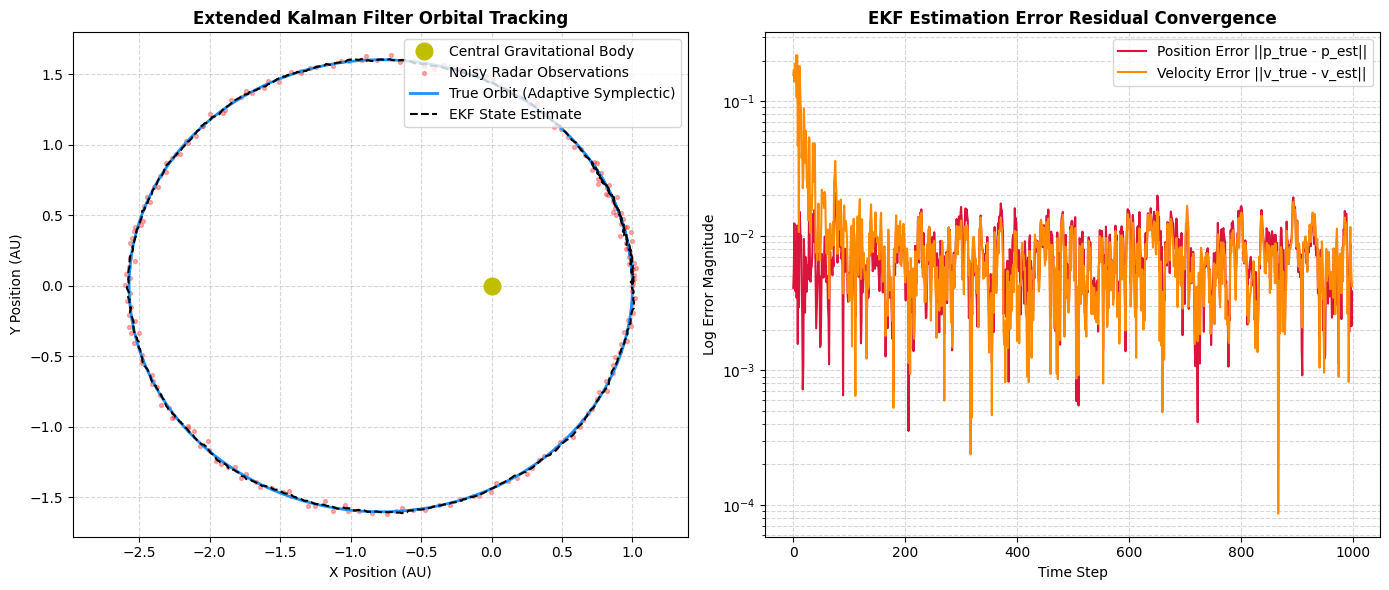

In [8]:
# --- 1. Compute State Estimation Errors ---
pos_error = np.linalg.norm(history_true[:, :2] - history_est[:, :2], axis=1)
vel_error = np.linalg.norm(history_true[:, 2:] - history_est[:, 2:], axis=1)

# Reconstruct noisy sensor positions in Cartesian coordinates for plotting
r_meas = history_meas[:, 0]
theta_meas = history_meas[:, 1]
meas_cart_x = r_meas * np.cos(theta_meas)
meas_cart_y = r_meas * np.sin(theta_meas)

# --- 2. Render Static Portfolio Dashboard ---
fig, (ax_orbit, ax_error) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Trajectory Tracking Map
ax_orbit.plot(0, 0, 'yo', markersize=12, label='Central Gravitational Body')
ax_orbit.scatter(meas_cart_x[::5], meas_cart_y[::5], color='red', s=8, alpha=0.3, label='Noisy Radar Observations')
ax_orbit.plot(history_true[:, 0], history_true[:, 1], color='dodgerblue', lw=2, label='True Orbit (Adaptive Symplectic)')
ax_orbit.plot(history_est[:, 0], history_est[:, 1], color='black', lw=1.5, linestyle='--', label='EKF State Estimate')

ax_orbit.set_title("Extended Kalman Filter Orbital Tracking", fontweight='bold')
ax_orbit.set_xlabel("X Position (AU)")
ax_orbit.set_ylabel("Y Position (AU)")
ax_orbit.axis('equal')
ax_orbit.grid(True, linestyle='--', alpha=0.5)
ax_orbit.legend(loc='upper right')

# Panel 2: State Error Convergence
time_steps = np.arange(num_steps)
ax_error.plot(time_steps, pos_error, color='crimson', lw=1.5, label='Position Error ||p_true - p_est||')
ax_error.plot(time_steps, vel_error, color='darkorange', lw=1.5, label='Velocity Error ||v_true - v_est||')

ax_error.set_yscale('log')
ax_error.set_title("EKF Estimation Error Residual Convergence", fontweight='bold')
ax_error.set_xlabel("Time Step")
ax_error.set_ylabel("Log Error Magnitude")
ax_error.grid(True, which="both", linestyle='--', alpha=0.5)
ax_error.legend(loc='upper right')

plt.tight_layout()
plt.savefig("orbits_ekf_results.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, FileLink

mpl.rcParams['animation.embed_limit'] = 100.0

# --- 1. Canvas Setup ---
fig, (ax_orbit, ax_error) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Dynamic Orbit Tracking
ax_orbit.plot(0, 0, 'yo', markersize=12, label='Central Body')
ax_orbit.plot(history_true[:, 0], history_true[:, 1], color='dodgerblue', alpha=0.3, lw=1.5, label='True Path')

# Dynamic elements
radar_scat = ax_orbit.scatter([], [], color='red', s=12, alpha=0.5, label='Noisy Radar')
true_pt, = ax_orbit.plot([], [], 'o', color='dodgerblue', markersize=7, label='True Position')
est_line, = ax_orbit.plot([], [], color='black', lw=1.5, linestyle='--', label='EKF Estimate')
est_pt, = ax_orbit.plot([], [], 'kx', markersize=8, markeredgewidth=2)

ax_orbit.set_xlim(-2.8, 1.4)
ax_orbit.set_ylim(-1.8, 1.8)
ax_orbit.set_title("Live EKF Orbital State Estimation", fontweight='bold')
ax_orbit.set_xlabel("X Position (AU)")
ax_orbit.set_ylabel("Y Position (AU)")
ax_orbit.grid(True, linestyle='--', alpha=0.5)
ax_orbit.legend(loc='upper right')

# Subplot 2: Dynamic Error Convergence
line_pos_err, = ax_error.plot([], [], color='crimson', lw=1.5, label='Position Error')
line_vel_err, = ax_error.plot([], [], color='darkorange', lw=1.5, label='Velocity Error')

ax_error.set_yscale('log')
ax_error.set_xlim(0, num_steps)
ax_error.set_ylim(min(np.min(pos_error), np.min(vel_error)) * 0.8, max(np.max(pos_error), np.max(vel_error)) * 1.2)
ax_error.set_title("EKF Residual Error Convergence", fontweight='bold')
ax_error.set_xlabel("Time Step")
ax_error.set_ylabel("Log Error Magnitude")
ax_error.grid(True, which="both", linestyle='--', alpha=0.5)
ax_error.legend(loc='upper right')

# --- 2. Animation Update Function ---
step_stride = 5  # Downsample frames for smooth execution and light file size
frame_indices = np.arange(0, num_steps, step_stride)

def update(frame_idx):
    # Radar points trailing window
    start_idx = max(0, frame_idx - 50)
    radar_scat.set_offsets(np.column_stack((meas_cart_x[start_idx:frame_idx], meas_cart_y[start_idx:frame_idx])))
    
    # Orbit trajectories
    true_pt.set_data([history_true[frame_idx, 0]], [history_true[frame_idx, 1]])
    est_line.set_data(history_est[:frame_idx, 0], history_est[:frame_idx, 1])
    est_pt.set_data([history_est[frame_idx, 0]], [history_est[frame_idx, 1]])
    
    # Error curves
    line_pos_err.set_data(time_steps[:frame_idx], pos_error[:frame_idx])
    line_vel_err.set_data(time_steps[:frame_idx], vel_error[:frame_idx])

# --- 3. Render and Save ---
anim = FuncAnimation(fig, update, frames=frame_indices, interval=30, blit=False)
anim.save("orbits_ekf_simulation.gif", writer='pillow', fps=30)
plt.close(fig)

# Display download link and inline player
display(FileLink("orbits_ekf_simulation.gif"))
display(FileLink("orbits_ekf_results.png"))
HTML(anim.to_jshtml())

/kaggle/working/orbits_ekf_simulation.gif

/kaggle/working/orbits_ekf_results.png

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# --- 1. PDE & Grid Parameters ---
GRID_SIZE = 100
Du, Dv = 0.16, 0.08      # Diffusion rates
F, k = 0.035, 0.060       # Feed and kill rates (Turing pattern regime)
dt = 1.0

# Initialize concentration fields U and V
U = np.ones((GRID_SIZE, GRID_SIZE))
V = np.zeros((GRID_SIZE, GRID_SIZE))

# Perturb central region to trigger pattern formation
r = 10
cx, cy = GRID_SIZE // 2, GRID_SIZE // 2
U[cx-r:cx+r, cy-r:cy+r] = 0.50
V[cx-r:cx+r, cy-r:cy+r] = 0.25
V += np.random.normal(0, 0.02, (GRID_SIZE, GRID_SIZE))
V = np.clip(V, 0, 1)

# 2D discrete Laplacian kernel
laplacian_kernel = np.array([
    [0.05, 0.20, 0.05],
    [0.20, -1.0, 0.20],
    [0.05, 0.20, 0.05]
])

def step_pde(U, V):
    """Step the Gray-Scott Reaction-Diffusion system forward in time."""
    Lu = convolve2d(U, laplacian_kernel, mode='same', boundary='wrap')
    Lv = convolve2d(V, laplacian_kernel, mode='same', boundary='wrap')
    
    uvv = U * (V**2)
    dU = (Du * Lu - uvv + F * (1.0 - U)) * dt
    dV = (Dv * Lv + uvv - (F + k) * V) * dt
    
    return np.clip(U + dU, 0, 1), np.clip(V + dV, 0, 1)

# --- 2. Agent Population Setup ---
NUM_AGENTS = 60
agent_pos = np.random.rand(NUM_AGENTS, 2) * GRID_SIZE
agent_health = np.ones(NUM_AGENTS) * 100.0

def update_agents(positions, health, field_V):
    """Update agent positions via spatial gradient chemotaxis."""
    gy, gx = np.gradient(field_V)
    
    for i in range(len(positions)):
        if health[i] <= 0:
            continue
            
        x = int(positions[i, 0]) % GRID_SIZE
        y = int(positions[i, 1]) % GRID_SIZE
        
        # Calculate steering vector along positive nutrient gradient grad(V)
        grad_x = gx[y, x]
        grad_y = gy[y, x]
        grad_mag = np.sqrt(grad_x**2 + grad_y**2) + 1e-6
        
        # Move agent toward higher concentration
        step_x = (grad_x / grad_mag) * 0.8 + np.random.uniform(-0.2, 0.2)
        step_y = (grad_y / grad_mag) * 0.8 + np.random.uniform(-0.2, 0.2)
        
        positions[i, 0] = (positions[i, 0] + step_x) % GRID_SIZE
        positions[i, 1] = (positions[i, 1] + step_y) % GRID_SIZE
        
        # Consume local resource and drain metabolic energy
        health[i] += field_V[y, x] * 5.0 - 0.4
        health[i] = min(health[i], 150.0)
        
    return positions, health

# --- 3. Warm-up Test Run ---
for _ in range(200):
    U, V = step_pde(U, V)

agent_pos, agent_health = update_agents(agent_pos, agent_health, V)

print("PDE Step Execution Completed.")
print(f"Mean Nutrient Field Concentration (V): {np.mean(V):.4f}")
print(f"Active Surviving Agents:                {np.sum(agent_health > 0)} / {NUM_AGENTS}")

PDE Step Execution Completed.
Mean Nutrient Field Concentration (V): 0.0094
Active Surviving Agents:                60 / 60


In [ ]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, FileLink

mpl.rcParams['animation.embed_limit'] = 100.0

# --- 1. Run Simulation History ---
sim_steps = 300
history_V = np.zeros((sim_steps, GRID_SIZE, GRID_SIZE))
history_agent_pos = np.zeros((sim_steps, NUM_AGENTS, 2))
history_agent_health = np.zeros((sim_steps, NUM_AGENTS))
history_survivors = np.zeros(sim_steps)
history_mean_V = np.zeros(sim_steps)

# Reset state
U = np.ones((GRID_SIZE, GRID_SIZE))
V = np.zeros((GRID_SIZE, GRID_SIZE))
U[cx-r:cx+r, cy-r:cy+r] = 0.50
V[cx-r:cx+r, cy-r:cy+r] = 0.25
V += np.random.normal(0, 0.02, (GRID_SIZE, GRID_SIZE))
V = np.clip(V, 0, 1)

agent_pos = np.random.rand(NUM_AGENTS, 2) * GRID_SIZE
agent_health = np.ones(NUM_AGENTS) * 100.0

for t in range(sim_steps):
    U, V = step_pde(U, V)
    agent_pos, agent_health = update_agents(agent_pos, agent_health, V)
    
    history_V[t] = V.copy()
    history_agent_pos[t] = agent_pos.copy()
    history_agent_health[t] = agent_health.copy()
    history_survivors[t] = np.sum(agent_health > 0)
    history_mean_V[t] = np.mean(V)

# --- 2. Canvas & Animation Setup ---
fig, (ax_pde, ax_metrics) = plt.subplots(1, 2, figsize=(14, 6))
plt.subplots_adjust(wspace=0.35)

# Panel 1: PDE Morphogen Heatmap + Agent Overlay
im = ax_pde.imshow(history_V[0], cmap='viridis', origin='lower', extent=[0, GRID_SIZE, 0, GRID_SIZE], vmin=0, vmax=0.4)
scat = ax_pde.scatter(history_agent_pos[0, :, 0], history_agent_pos[0, :, 1], 
                      c=history_agent_health[0], cmap='plasma', edgecolors='white', s=25, linewidths=0.5)

cbar = fig.colorbar(im, ax=ax_pde, fraction=0.046, pad=0.04)
cbar.set_label("Nutrient Concentration (V)")
ax_pde.set_title("Gray-Scott PDE Field & Agent Chemotaxis", fontweight='bold')
ax_pde.set_xlabel("Spatial X")
ax_pde.set_ylabel("Spatial Y")

# Panel 2: Live Population Metrics
time_axis = np.arange(sim_steps)
line_surv, = ax_metrics.plot([], [], color='crimson', lw=2, label='Surviving Agents')
ax_metrics_twin = ax_metrics.twinx()
line_field, = ax_metrics_twin.plot([], [], color='teal', lw=1.5, linestyle='--', label='Mean Field V Density')

ax_metrics.set_xlim(0, sim_steps)
ax_metrics.set_ylim(0, NUM_AGENTS * 1.1)
ax_metrics_twin.set_ylim(0, max(history_mean_V) * 1.3 + 1e-4)

ax_metrics.set_title("System Dynamics & Nutrient Consumption", fontweight='bold')
ax_metrics.set_xlabel("PDE Simulation Step")
ax_metrics.set_ylabel("Surviving Agent Count", color='crimson')
ax_metrics_twin.set_ylabel("Average Field V Density", color='teal')
ax_metrics.grid(True, linestyle='--', alpha=0.5)

# Combine legends
lines = [line_surv, line_field]
labels = [l.get_label() for l in lines]
ax_metrics.legend(lines, labels, loc='upper left')

# --- 3. Animation Function ---
def update(frame):
    # Update PDE field mesh & agent scatters
    im.set_array(history_V[frame])
    
    # Filter active agents for rendering
    active_mask = history_agent_health[frame] > 0
    scat.set_offsets(history_agent_pos[frame, active_mask])
    scat.set_array(history_agent_health[frame, active_mask])
    
    # Update telemetry curves
    line_surv.set_data(time_axis[:frame], history_survivors[:frame])
    line_field.set_data(time_axis[:frame], history_mean_V[:frame])

# --- 4. Export GIF ---
anim = FuncAnimation(fig, update, frames=sim_steps, interval=40, blit=False)
anim.save("ecosystem_pde_simulation.gif", writer='pillow', fps=25)
plt.close(fig)

# Display download link and inline player
display(FileLink("ecosystem_pde_simulation.gif"))
HTML(anim.to_jshtml())

/kaggle/working/ecosystem_pde_simulation.gif